---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 11. Тиристорні прилади</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Чотиришарова p-n-p-n структура і двотранзисторна модель</li>
  <li>Диністор: конструкція, ВАХ, релаксаційний генератор</li>
  <li>Тиристор з керуючим електродом: параметри, керований випрямляч</li>
  <li>Симетричні тиристори (симістори) і регулятори потужності</li>
  <li>Способи увімкнення і вимкнення тиристорів, перехідні процеси</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 11 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Чотиришарова p-n-p-n структура](#pnpn)
    * [🔬 Інтерактивно: S-подібна ВАХ з двотранзисторної моделі](#iv-model)
* [Диністор](#dinistor)
    * [🔬 Інтерактивно: релаксаційний генератор на диністорі](#spice-relax)
* [Тиристор з керуючим електродом](#scr)
    * [⚙️ PySpice: ВАХ тиристора при різних струмах керування](#spice-scr-iv)
    * [⚙️ PySpice: керований випрямляч](#spice-phase)
* [Симетричні тиристори (симістори)](#triac)
    * [⚙️ PySpice: симісторний регулятор потужності](#spice-triac)
* [Увімкнення та вимкнення тиристорів. Перехідні процеси](#switching)
    * [⚙️ PySpice: процес увімкнення і помилкове ввімкнення через dU/dt](#spice-turnon)
    * [⚙️ PySpice: вимкнення і час відновлення керованості](#spice-turnoff)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

from PySpice.Spice.Netlist import SubCircuit

class SCR(SubCircuit):
    """Тиристор: двотранзисторна модель p-n-p + n-p-n, вузли A G K.
    ubo — напруга вмикання (лавинний пробій середнього переходу J2), rgk — внутрішній опір керуючий електрод–катод."""
    NODES = ('A', 'G', 'K')
    def __init__(self, name='SCR', ubo=600, rgk=1e3):
        super().__init__(name, *self.NODES)
        self.model('QP_' + name, 'PNP', IS=1e-14, BF=0.25, BR=0.3, TF=1e-6, TR=5e-6, CJE=50e-12, CJC=50e-12)   # широка база n1: α1 ≈ 0,2
        self.model('QN_' + name, 'NPN', IS=1e-14, BF=50, BR=0.3, TF=1e-7, TR=2e-6, CJE=50e-12, CJC=50e-12)     # вузька база p2: α2 ≈ 0,98
        self.model('DB_' + name, 'D', IS=1e-15, BV=ubo, IBV=1e-6)
        self.BJT('P', 'G', 'n1', 'A', model='QP_' + name)     # p-n-p: емітер p1 (A), база n1, колектор p2 (G)
        self.BJT('N', 'n1', 'G', 'K', model='QN_' + name)     # n-p-n: колектор n1, база p2 (G), емітер n2 (K)
        self.D('BO', 'G', 'n1', model='DB_' + name)           # пробій середнього переходу J2 -> вмикання по аноду
        self.R('GK', 'G', 'K', rgk)

class TRIAC(SubCircuit):
    """Симістор: два зустрічно-паралельні тиристори; струм керування будь-якого знаку вмикає обидві структури."""
    NODES = ('MT2', 'G', 'MT1')
    def __init__(self, name='TRIAC', ubo=600):
        super().__init__(name, *self.NODES)
        self.subcircuit(SCR('SCR_' + name, ubo=ubo))
        self.V('sense', 'G', 'gin', 0)
        self.R('gin', 'gin', 'MT1', 50)                       # вхідний опір кола керування
        self.X('1', 'SCR_' + name, 'MT2', 'g1', 'MT1')
        self.X('2', 'SCR_' + name, 'MT1', 'g2', 'MT2')
        self.B('m1', 'MT1', 'g1', i='abs(i(vsense))')         # |I_КЕ| будь-якого знаку вмикає обидві структури
        self.B('m2', 'MT2', 'g2', i='abs(i(vsense))')         # (спрощено: усі чотири квадранти однаково чутливі)

---

# Чотиришарова p-n-p-n структура <a class="anchor" id="pnpn"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати будову p-n-p-n структури і роль трьох її переходів
> - Виводити умову вмикання тиристора з двотранзисторної моделі ($\alpha_1+\alpha_2 \to 1$)
> - Описувати конструкцію, ВАХ і застосування диністора, тиристора і симістора
> - Перелічувати способи увімкнення та вимкнення тиристорів
> - Пояснювати перехідні процеси при вмиканні й вимиканні, параметри $di/dt$, $dU/dt$ і $t_q$
> - Розраховувати керований випрямляч і фазовий регулятор потужності

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Тиристор** | Напівпровідниковий прилад з трьома і більше p-n переходами, ВАХ якого має ділянку від'ємного опору; працює як ключ з двома стійкими станами |
| **Напруга вмикання $U_{вмк}$ ($U_{BO}$)** | Анодна напруга, при якій закритий тиристор перемикається у відкритий стан без сигналу керування |
| **Струм утримання $I_{утр}$ ($I_H$)** | Мінімальний анодний струм, при якому тиристор залишається відкритим |
| **Струм вмикання $I_{к.вмк}$ ($I_{GT}$)** | Мінімальний струм керуючого електрода, що гарантовано відкриває тиристор |
| **Час вимикання $t_q$** | Мінімальний інтервал між спаданням анодного струму до нуля і повторним прикладанням прямої напруги, після якого тиристор її витримує |
| **Критична $dU/dt$** | Швидкість наростання прямої напруги, вище якої тиристор вмикається сам через ємнісний струм переходу |

**Тиристор** — чотиришарова структура **p1-n1-p2-n2** з трьома послідовними переходами J1, J2, J3. Зовнішні шари — **анод** (p1) і **катод** (n2), від внутрішнього шару p2 (рідше n1) робиться вивід **керуючого електрода** (КЕ, gate). При прямій напрузі ($U_{АК}>0$) крайні переходи J1 і J3 зміщені прямо, а середній **J2 — зворотно**: він і тримає всю напругу, тому тиристор закритий. При зворотній напрузі закриті J1 і J3.

**Двотранзисторна модель.** Структуру можна «розрізати» по шарах n1 і p2 на два транзистори: **p-n-p** (p1-n1-p2, коефіцієнт передачі $\alpha_1$) і **n-p-n** (n2-p2-n1, $\alpha_2$). Колектор кожного живить базу іншого — це **додатний зворотний зв'язок**. Струм через перехід J2 складається зі струмів обох колекторів і теплового струму $I_{КБО}$:

$$I_А = \alpha_1 I_А + \alpha_2 I_К + I_{КБО}, \quad I_К = I_А + I_К^{(КЕ)} \;\;\Rightarrow\;\; I_А = \frac{\alpha_2 I_{КЕ} + I_{КБО}}{1-(\alpha_1+\alpha_2)} .$$

Коефіцієнти $\alpha$ кремнієвих транзисторів **зростають зі струмом** (на малих струмах переважає рекомбінація в ОПЗ). Поки струм малий і $\alpha_1+\alpha_2 < 1$, анодний струм обмежений — **закритий стан**. Якщо будь-яким способом збільшити струм так, що $\alpha_1+\alpha_2 \to 1$, знаменник прямує до нуля, струм лавиноподібно зростає, обидва транзистори входять у насичення, перехід J2 зміщується прямо — **відкритий стан** з напругою $U_{відкр}\approx 1$–2 В. З урахуванням лавинного множення $M(U)$ у переході J2:

$$I_А = \frac{M(\alpha_2 I_{КЕ} + I_{КБО})}{1-M(\alpha_1+\alpha_2)}, \qquad M = \frac{1}{1-(U/U_{проб})^n} .$$

**ВАХ** має чотири ділянки: 1 — закритий стан (малий струм витоку); 2 — ділянка **від'ємного диференціального опору** (нестійка, на практиці проскакується); 3 — відкритий стан (як пряма гілка діода); 4 — зворотна гілка (як у закритого діода, до зворотного пробою).

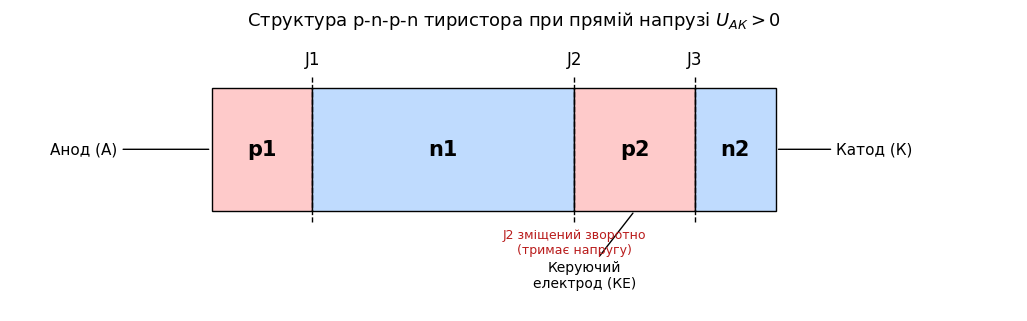

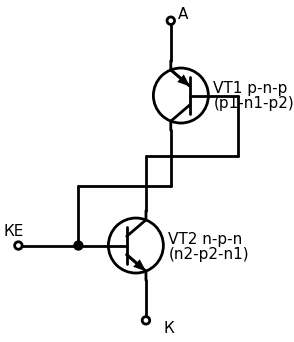

In [2]:
# Шарова структура тиристора і двотранзисторна еквівалентна схема
fig, ax = plt.subplots(figsize=(13, 3.6))
layers = [('p1', '#fecaca', 1.0), ('n1', '#bfdbfe', 2.6), ('p2', '#fecaca', 1.2), ('n2', '#bfdbfe', 0.8)]
x = 0
for name, col, w in layers:
    ax.add_patch(patches.Rectangle((x, 0), w, 1.6, facecolor=col, edgecolor='k'))
    ax.text(x + w/2, 0.8, name, ha='center', va='center', fontsize=15, weight='bold')
    x += w
xs = np.cumsum([w for _, _, w in layers])[:-1]
for k, xj in enumerate(xs, 1):
    ax.plot([xj, xj], [-0.15, 1.75], 'k--', lw=1)
    ax.text(xj, 1.9, f'J{k}', ha='center', fontsize=12)
ax.annotate('Анод (А)', xy=(0, 0.8), xytext=(-1.6, 0.8), va='center', arrowprops=dict(arrowstyle='-'), fontsize=11)
ax.annotate('Катод (К)', xy=(x, 0.8), xytext=(x + 0.6, 0.8), va='center', arrowprops=dict(arrowstyle='-'), fontsize=11)
ax.annotate('Керуючий\nелектрод (КЕ)', xy=(xs[1] + 0.6, 0), xytext=(xs[1] + 0.1, -1.0), ha='center', arrowprops=dict(arrowstyle='-'), fontsize=10)
ax.text(xs[1], -0.55, 'J2 зміщений зворотно\n(тримає напругу)', ha='center', fontsize=9, color='#b91c1c')
ax.set_xlim(-2, x + 2.4); ax.set_ylim(-1.3, 2.3); ax.axis('off')
ax.set_title('Структура p-n-p-n тиристора при прямій напрузі $U_{АК}>0$')
plt.show()

if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2.5) as d:
        qp = d.add(elm.BjtPnp(circle=True).right().reverse().anchor('base').at((2.0, 0)).label('VT1 p-n-p\n(p1-n1-p2)', loc='right'))
        qn = d.add(elm.BjtNpn(circle=True).right().anchor('base').at((0.0, -3.0)).label('VT2 n-p-n\n(n2-p2-n1)', loc='right'))
        xe, ye = qp.emitter; xc, yc = qp.collector
        d.add(elm.Line().endpoints((xe, ye), (xe, ye + 0.8))); d.add(elm.Dot(open=True).at((xe, ye + 0.8)))
        d.add(elm.Label().at((xe + 0.35, ye + 0.85)).label('А'))
        # колектор VT1 -> база VT2 (струм α1·I_А живить базу n-p-n)
        d.add(elm.Line().endpoints((xc, yc), (xc, -1.8))); d.add(elm.Line().endpoints((xc, -1.8), (-0.6, -1.8)))
        d.add(elm.Line().endpoints((-0.6, -1.8), (-0.6, -3.0))); d.add(elm.Line().endpoints((-0.6, -3.0), (0.0, -3.0)))
        d.add(elm.Dot().at((-0.6, -3.0)))
        d.add(elm.Line().endpoints((-0.6, -3.0), (-1.8, -3.0))); d.add(elm.Dot(open=True).at((-1.8, -3.0)))
        d.add(elm.Label().at((-1.8, -2.6)).label('КЕ'))
        # колектор VT2 -> база VT1
        xn, yn = qn.collector
        d.add(elm.Line().endpoints((xn, yn), (xn, -1.2))); d.add(elm.Line().endpoints((xn, -1.2), (2.6, -1.2)))
        d.add(elm.Line().endpoints((2.6, -1.2), (2.6, 0.0))); d.add(elm.Line().endpoints((2.6, 0.0), (2.0, 0.0)))
        xk, yk = qn.emitter
        d.add(elm.Line().endpoints((xk, yk), (xk, yk - 0.8))); d.add(elm.Dot(open=True).at((xk, yk - 0.8)))
        d.add(elm.Label().at((xk + 0.35, yk - 0.85)).label('К'))

### 🔬 Інтерактивно: S-подібна ВАХ з двотранзисторної моделі <a class="anchor" id="iv-model"></a>

Розрахунок за формулою з лавинним множенням: $\alpha_{1,2}(I) = \alpha_{0}\,I/(I+I_{α})$ зростають зі струмом, $M(U)$ — за емпіричною формулою Міллера. Струм відкладено в логарифмічному масштабі — інакше мікроамперні струми закритого стану й ділянку від'ємного опору не видно. Збільшуйте струм керування: напруга вмикання знижується, і при $I_{КЕ} \ge I_{к.вмк}$ тиристор вмикається практично при нульовій напрузі — ВАХ «спрямляється».

In [3]:
def thyristor_iv(I_g_mA=0.0, U_br=400.0, a1=0.45, a2=0.75):
    I = np.logspace(-9, 1, 4000)                          # анодний струм, А
    alpha1 = a1*I/(I + 2e-4); alpha2 = a2*I/(I + 5e-5)   # α зростають зі струмом
    I0, n, Ig = 1e-8, 4.0, I_g_mA*1e-3
    Mreq = I/(I*(alpha1 + alpha2) + alpha2*Ig + I0)       # з I(1 - M(α1+α2)) = M(α2 Ig + I0)
    blocking = Mreq >= 1
    U = np.where(blocking, U_br*(1 - 1/np.where(blocking, Mreq, 1))**(1/n), np.nan)
    U_on = 0.9 + 0.05*I                                    # відкритий стан
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2.2, 1]})
    ax = axes[0]
    ax.semilogy(U, I, color='#2563eb', label='закритий стан → ділянка від\'ємного опору')
    on = (~blocking) & (I > 1e-5)
    ax.semilogy(U_on[on], I[on], color='#dc2626', label='відкритий стан')
    k = np.nanargmax(U)
    ax.plot(U[k], I[k], 'ko'); ax.annotate(f'$U_{{вмк}}$ ≈ {U[k]:.0f} В, $I_{{вмк}}$ ≈ {I[k]*1e6:.0f} мкА', (U[k], I[k]),
                                          xytext=(-150, 25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
    I_H = I[on][0]
    ax.axhline(I_H, color='gray', ls=':', lw=1); ax.text(U_br*0.45, I_H*1.4, f'$I_{{утр}}$ ≈ {I_H*1e3:.2f} мА', fontsize=9)
    ax.set_xlim(-5, U_br*1.1); ax.set_ylim(1e-9, 10)
    ax.set_xlabel('$U_{АК}$, В'); ax.set_ylabel('$I_А$, А'); ax.legend(fontsize=9, loc='lower right')
    ax.set_title(f'Пряма гілка ВАХ тиристора, $I_{{КЕ}}$ = {I_g_mA:.2f} мА (логарифмічний масштаб струму)')
    ax.grid(True, which='both', alpha=0.3)
    Ur = np.linspace(0, U_br*0.995, 400)
    axes[1].semilogy(-Ur, I0/(1 - (Ur/U_br)**n), color='#16a34a')
    axes[1].set_xlabel('$U_{АК}$, В'); axes[1].set_ylabel('$|I_А|$, А'); axes[1].set_title('Зворотна гілка (як у закритого діода)')
    axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()

interact(thyristor_iv,
         I_g_mA=widgets.FloatSlider(min=0, max=0.6, step=0.02, value=0, description='$I_{КЕ}$, мА', continuous_update=False),
         U_br=widgets.IntSlider(min=100, max=1000, step=50, value=400, description='$U_{проб}$, В', continuous_update=False),
         a1=widgets.FloatSlider(min=0.2, max=0.6, step=0.05, value=0.45, description='$\\alpha_{1,max}$', continuous_update=False),
         a2=widgets.FloatSlider(min=0.5, max=0.95, step=0.05, value=0.75, description='$\\alpha_{2,max}$', continuous_update=False));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='$I_{КЕ}$, мА', max=0.6, ste…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Тиристор **не можна вимкнути, знявши сигнал керування**: після вмикання додатний зворотний зв'язок сам підтримує насичення обох транзисторів, і керуючий електрод втрачає вплив. Вимкнути звичайний тиристор можна лише зменшенням анодного струму нижче $I_{утр}$ (або зміною полярності анодної напруги). Виняток — **запірні тиристори (GTO)**, у яких великий від'ємний струм керування «витягує» носії з бази p2.

</div>

---

# Диністор <a class="anchor" id="dinistor"></a>

**Диністор** (діодний тиристор) — двоелектродна p-n-p-n структура **без керуючого електрода**. Вмикається він єдиним способом — збільшенням анодної напруги до **напруги вмикання** $U_{вмк}$: лавинне множення в переході J2 збільшує струм, $\alpha_1+\alpha_2$ досягає 1, і прилад перемикається у відкритий стан. Вимикається — зменшенням струму нижче $I_{утр}$.

**Конструкція.** Кремнієва пластина з дифузійними шарами p1-n1-p2-n2; керованість $U_{вмк}$ задається товщиною і легуванням бази n1. Щоб $U_{вмк}$ не залежала від випадкових витоків, шар p2 частково **шунтують** металізацією катода («закорочений емітер»). Вітчизняні диністори КН102А–И мають $U_{вмк}$ = 20–150 В, $I_{утр}$ ≤ 15 мА.

**Основні параметри:** $U_{вмк}$ і струм вмикання $I_{вмк}$; струм утримання $I_{утр}$; напруга у відкритому стані $U_{відкр}$ (1–2 В при максимальному струмі); максимальний середній струм $I_{відкр.max}$; час вмикання і вимикання.

**Симетричний диністор (діак, DIAC)** — трьох- або п'ятишарова структура з симетричною ВАХ, що вмикається при $|U| \ge U_{вмк}$ (DB3: 28–36 В) в обох напрямках. Застосовується переважно для **формування імпульсів керування симісторами** у фазових регуляторах.

**Застосування диністорів:** релаксаційні генератори пилкоподібної напруги та імпульсів, формувачі запускаючих імпульсів для тиристорів, захисні ланцюги (кроубари), лічильні та пам'ятні схеми з двома стійкими станами.

### 🔬 Інтерактивно: релаксаційний генератор на диністорі <a class="anchor" id="spice-relax"></a>

Конденсатор $C$ заряджається від джерела $E$ через резистор $R$. Коли напруга на ньому досягає $U_{вмк}$, диністор відкривається і розряджає $C$ через невеликий опір навантаження $R_н$ — на ньому формується імпульс струму. Коли струм диністора зменшиться нижче $I_{утр}$, диністор вимикається, і цикл повторюється. Генерація можлива за двох умов:

* струм від джерела в момент досягнення $U_{вмк}$ має перевищувати струм вмикання: $(E-U_{вмк})/R > I_{вмк}$ — інакше напруга «зупиниться» на $U_{вмк}$;
* струм від джерела у відкритому стані має бути меншим за струм утримання: $(E-U_{відкр})/R < I_{утр}$ — інакше диністор не вимкнеться.

Період коливань

$$T \approx RC\ln\frac{E - U_{відкр}}{E - U_{вмк}} .$$

Модель тут — покрокове чисельне розв'язання рівняння заряду конденсатора з диністором як ключем з гістерезисом (параметри КН102Б: $U_{вмк}$ = 28 В, $I_{вмк}$ = 0,1 мА, $I_{утр}$ = 5 мА, $U_{відкр}$ = 1,2 В).

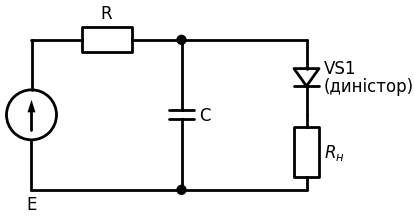

In [4]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        d.add(EMF().endpoints((0, 0), (0, 3)).label('E', loc='left'))
        d.add(elm.Resistor().endpoints((0, 3), (3, 3)).label('R'))
        d.add(elm.Dot().at((3, 3)))
        d.add(elm.Capacitor().endpoints((3, 3), (3, 0)).label('C', loc='bottom'))
        d.add(elm.Line().endpoints((3, 3), (5.5, 3)))
        d.add(elm.Diode().endpoints((5.5, 3), (5.5, 1.5)).label('VS1\n(диністор)', loc='bottom'))
        d.add(elm.Resistor().endpoints((5.5, 1.5), (5.5, 0)).label('$R_н$', loc='bottom'))
        d.add(elm.Line().endpoints((5.5, 0), (0, 0))); d.add(elm.Dot().at((3, 0)))

In [5]:
def relaxation(E=60.0, R_kOhm=20, C_uF=0.47):
    U_bo, I_bo, I_h, U_on, R_on, R_load = 28.0, 0.1e-3, 5e-3, 1.2, 2.0, 10.0
    R, C = R_kOhm*1e3, C_uF*1e-6
    tau = R*C
    T_est = tau*np.log((E - U_on)/(E - U_bo)) if E > U_bo else np.inf
    t_end = min(6*T_est, 20*tau) if np.isfinite(T_est) else 5*tau
    dt = min(t_end/200000, (R_on + R_load)*C/20)
    n = int(t_end/dt)
    uc, on = 0.0, False
    t_arr, uc_arr, i_arr = np.empty(n), np.empty(n), np.empty(n)
    for k in range(n):
        i_src = (E - uc)/R
        if on:
            i_d = max(uc - U_on, 0)/(R_on + R_load)            # розряд C через відкритий диністор і Rн
            if i_d < I_h:
                on = False                                     # струм менший за струм утримання -> вимкнення
        if not on:
            i_d = 0.0
            if uc >= U_bo:
                if i_src > I_bo:
                    on = True                                  # пробій J2 і достатній струм -> вмикання
                    i_d = max(uc - U_on, 0)/(R_on + R_load)
                else:
                    i_d = i_src                                # лише «пробитий» перехід: напруга тримається на U_вмк
        uc += (i_src - i_d)/C*dt
        t_arr[k], uc_arr[k], i_arr[k] = k*dt, uc, i_d
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(t_arr*1e3, uc_arr, color='#2563eb'); axes[0].axhline(U_bo, color='r', ls='--', lw=1)
    axes[0].text(0, U_bo + 1, '$U_{вмк}$', color='r'); axes[0].set_ylabel('$u_C$, В')
    axes[0].set_title(f'Релаксаційний генератор: E = {E} В, R = {R_kOhm} кОм, C = {C_uF} мкФ')
    axes[1].plot(t_arr*1e3, i_arr*1e3, color='#dc2626'); axes[1].set_ylabel('струм диністора, мА'); axes[1].set_xlabel('t, мс')
    plt.tight_layout(); plt.show()
    i_start, i_hold = (E - U_bo)/R, (E - U_on)/R
    print(f'(E - U_вмк)/R = {i_start*1e3:.3f} мА (потрібно > I_вмк = {I_bo*1e3} мА);  '
          f'(E - U_відкр)/R = {i_hold*1e3:.2f} мА (потрібно < I_утр = {I_h*1e3:g} мА)')
    pulses = np.sum(np.diff((i_arr > I_h).astype(int)) == 1)
    if E <= U_bo:
        print('E < U_вмк — диністор ніколи не вмикається.')
    elif i_start <= I_bo:
        print('Коливань немає: напруга зупинилась на U_вмк — струму недостатньо для вмикання.')
    elif i_hold >= I_h:
        print('Коливань немає: після першого імпульсу диністор залишився відкритим (струм джерела > I_утр).')
    else:
        print(f'Генерація: {pulses} імпульсів; період T ≈ RC·ln((E-U_відкр)/(E-U_вмк)) = {T_est*1e3:.2f} мс, f ≈ {1/T_est:.1f} Гц')

interact(relaxation,
         E=widgets.FloatSlider(min=20, max=150, step=5, value=60, description='E, В', continuous_update=False),
         R_kOhm=widgets.SelectionSlider(options=[2, 5, 10, 20, 50, 100, 200, 500, 1000], value=20, description='R, кОм',
                                        continuous_update=False),
         C_uF=widgets.SelectionSlider(options=[0.1, 0.22, 0.47, 1.0, 2.2], value=0.47, description='C, мкФ', continuous_update=False));

interactive(children=(FloatSlider(value=60.0, continuous_update=False, description='E, В', max=150.0, min=20.0…

---

# Тиристор з керуючим електродом <a class="anchor" id="scr"></a>

**Тріодний тиристор** (SCR — silicon controlled rectifier, на схемах **VS**) має вивід від бази p2 (катодне керування) або n1 (анодне керування). Струм керуючого електрода $I_{КЕ}$ вводиться в базу n-p-n транзистора, збільшує $\alpha_2$ і дозволяє ввімкнути тиристор при напрузі, значно меншій за $U_{вмк}$. Тому тиристор працює як **керований ключ**: закритий, доки не подано імпульс керування, і відкритий після нього — до спадання струму нижче $I_{утр}$.

**Конструкція.** Потужні тиристори виготовляють на кремнієвих дисках діаметром до 150 мм (струми — тисячі ампер, напруги — до 8–10 кВ); катод виконують у вигляді розгалуженої («евольвентної») структури, щоб відкривався одночасно великий периметр. Корпуси: штирові, таблеткові (притискні, з двостороннім охолодженням), модулі; малопотужні — TO-92, TO-220.

| Параметр | Позначення | Типові значення |
|---|---|---|
| Повторювана імпульсна напруга в закритому стані / зворотна | $U_{DRM}$, $U_{RRM}$ | 400–8000 В |
| Середній / ударний струм у відкритому стані | $I_{T(AV)}$, $I_{TSM}$ | 0,8–5000 А / до 100 кА |
| Напруга у відкритому стані | $U_T$ | 1–2,5 В |
| Струм / напруга керування, що відкриває | $I_{GT}$, $U_{GT}$ | 0,2–200 мА / 0,7–3 В |
| Струм утримання і струм вмикання (latching) | $I_H$, $I_L$ | 1–500 мА, $I_L \approx (2\ldots3)I_H$ |
| Критична швидкість наростання струму / напруги | $di/dt$, $dU/dt$ | 50–1000 А/мкс / 50–2000 В/мкс |
| Час вмикання / вимикання | $t_{gt}$, $t_q$ | 1–5 мкс / 10–500 мкс |

**Різновиди:** запірні (GTO) і з комутацією через керуючий електрод (IGCT) — вимикаються від'ємним імпульсом керування; асиметричні (без зворотної блокуючої здатності, з малим $t_q$); тиристори-діоди (з вбудованим зустрічно-паралельним діодом); **фототиристори** (оптотиристори) — вмикаються світлом, використовуються у високовольтних перетворювачах постійного струму.

**Застосування:** керовані випрямлячі (регульовані джерела, електроприводи постійного струму, зарядні пристрої), регулятори змінної напруги, пристрої плавного пуску двигунів, інвертори, лінії передачі постійного струму надвисокої напруги (HVDC), системи захисту (кроубари).

### ⚙️ PySpice: ВАХ тиристора при різних струмах керування <a class="anchor" id="spice-scr-iv"></a>

Модель тиристора — двотранзисторна підсхема `SCR` (див. комірку налаштування): p-n-p і n-p-n транзистори Гуммеля–Пуна, діод з пробоєм $U_{вмк}$ паралельно переходу J2 і внутрішній опір КЕ–катод. Щоб побачити ділянку від'ємного опору, розгортається не напруга, а **анодний струм** (при розгортці напруги прилад «перескакує» цю нестійку ділянку).

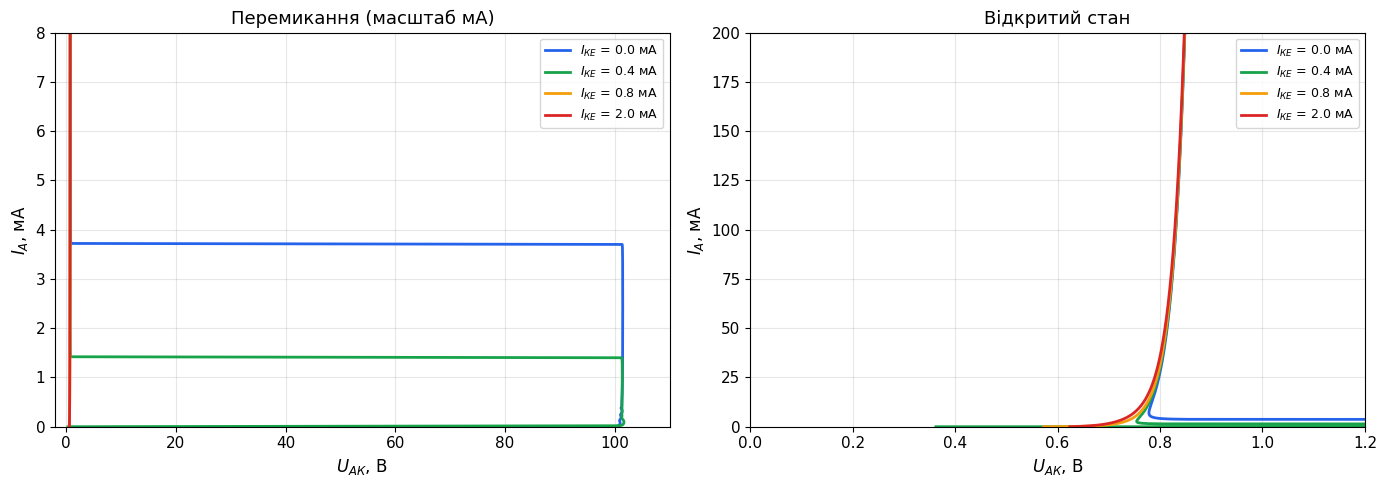

In [6]:
c = Circuit('SCR IV'); c.subcircuit(SCR('SCR100', ubo=100))
c.I('a', c.gnd, 'a', 0); c.I('g', c.gnd, 'g', 0)
c.X('1', 'SCR100', 'a', 'g', c.gnd)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ig, col in [(0, '#2563eb'), (0.4e-3, '#16a34a'), (0.8e-3, '#f59e0b'), (2e-3, '#dc2626')]:
    c['Ig'].dc_value = ig
    an = c.simulator().dc(Ia=slice(1e-9, 0.2, 2e-5))
    I, U = np.array(an.sweep), np.array(an['a'])
    for ax in axes:
        ax.plot(U, I*1e3, color=col, label=f'$I_{{КЕ}}$ = {ig*1e3:.1f} мА')
axes[0].set_xlim(-2, 110); axes[0].set_ylim(0, 8); axes[0].set_title('Перемикання (масштаб мА)')
axes[1].set_xlim(0, 1.2); axes[1].set_ylim(0, 200); axes[1].set_title('Відкритий стан')
for ax in axes:
    ax.set_xlabel('$U_{АК}$, В'); ax.set_ylabel('$I_А$, мА'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Поки струм керування менший за $I_{GT}$ (тут ≈ 0,6 мА ≈ $U_{БЕ}/R_{КЕ-К}$ — визначається внутрішнім опором КЕ–катод 1 кОм), тиристор вмикається лише при $U_{вмк}$. Більший струм вводить n-p-n транзистор в активний режим уже при нульовій анодній напрузі — тиристор вмикається відразу. У відкритому стані ВАХ збігається з прямою гілкою діода ($U_T$ ≈ 0,8–0,9 В).

### ⚙️ PySpice: керований випрямляч <a class="anchor" id="spice-phase"></a>

**Фазове керування.** Тиристор вмикається імпульсом керування з **кутом керування** $\alpha$ відносно початку додатного півперіоду і вимикається природно, коли струм спадає до нуля. Для однопівперіодного випрямляча з активним навантаженням середня напруга

$$U_d = \frac{U_m}{2\pi}(1+\cos\alpha).$$

З індуктивним навантаженням струм триває і після переходу напруги через нуль — тиристор вимикається пізніше, а $U_d$ зменшується.

In [7]:
def phase_rectifier(alpha=60, load='R', L_mH=0):
    f, Um, R = 50.0, 325.0, 100.0
    c = Circuit('Phase-controlled rectifier'); c.subcircuit(SCR('SCR600', ubo=800))
    c.SinusoidalVoltageSource('s', 'in', c.gnd, amplitude=Um, frequency=f)
    if load == 'RL' and L_mH > 0:
        c.R('L', 'in', 'm', R); c.L('L', 'm', 'a', L_mH*1e-3)
    else:
        c.R('L', 'in', 'a', R)
    c.PulseVoltageSource('g', 'gs', c.gnd, initial_value=0, pulsed_value=5, delay_time=alpha/360/f,
                         rise_time=1e-6, fall_time=1e-6, pulse_width=100e-6, period=1/f)
    c.R('g', 'gs', 'g', 1e3)
    c.X('1', 'SCR600', 'a', 'g', c.gnd)
    an = c.simulator().transient(step_time=10e-6, end_time=0.08, max_time=20e-6)
    t = np.array(an.time); u_in = np.array(an['in']); u_ak = np.array(an['a'])
    u_load = u_in - u_ak
    i = u_load/R if not (load == 'RL' and L_mH > 0) else (u_in - np.array(an['m']))/R
    m = t >= 0.04
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)
    axes[0].plot(t[m]*1e3, u_in[m], color='gray', lw=1, label='$u_{мережі}$')
    axes[0].plot(t[m]*1e3, u_load[m], color='#dc2626', lw=2, label='$u_{нав}$')
    axes[0].plot(t[m]*1e3, u_ak[m], color='#2563eb', lw=1, label='$u_{АК}$')
    axes[0].set_ylabel('U, В'); axes[0].legend(fontsize=9, loc='lower left')
    axes[1].plot(t[m]*1e3, i[m], color='#16a34a'); axes[1].set_ylabel('$i_А$, А'); axes[1].set_xlabel('t, мс')
    axes[0].set_title(f'Керований випрямляч: α = {alpha}°, навантаження {load}' + (f', L = {L_mH} мГн' if load == 'RL' else ''))
    plt.tight_layout(); plt.show()
    Ud = np.trapezoid(u_load[m], t[m])/(t[m][-1] - t[m][0])     # усереднення за часом (крок ngspice нерівномірний)
    Ud_th = Um/(2*np.pi)*(1 + np.cos(np.radians(alpha)))
    print(f'Середня напруга на навантаженні: моделювання {Ud:.1f} В; формула для R-навантаження {Ud_th:.1f} В')

interact(phase_rectifier,
         alpha=widgets.IntSlider(min=10, max=170, step=10, value=60, description='α, °', continuous_update=False),
         load=widgets.ToggleButtons(options=['R', 'RL'], description='Навантаження'),
         L_mH=widgets.SelectionSlider(options=[0, 50, 100, 200, 500], value=200, description='L, мГн', continuous_update=False));

interactive(children=(IntSlider(value=60, continuous_update=False, description='α, °', max=170, min=10, step=1…

---

# Симетричні тиристори (симістори) <a class="anchor" id="triac"></a>

**Симістор** (симетричний тиристор, TRIAC) проводить струм **в обох напрямках** і замінює два зустрічно-паралельно ввімкнені тиристори з одним керуючим електродом. Виводи: **основні електроди** Т1 (MT1, «катод» — відносно нього подається керування) і Т2 (MT2), та керуючий електрод.

**Конструкція.** П'ятишарова структура **n-p-n-p-n**: в одній кремнієвій пластині сформовано дві зустрічні тиристорні структури p1-n1-p2-n2 і p2-n1-p1-n3, а також допоміжна область n4 біля керуючого електрода, що дає змогу вмикати прилад струмом керування будь-якої полярності. ВАХ симетрична: в I і III квадрантах — по S-подібній гілці.

**Чотири режими (квадранти) керування** (знак $U_{T2-T1}$ / знак $I_{КЕ}$): I+ (+/+) і III− (−/−) — найчутливіші; I− (+/−) — чутливість менша; III+ (−/+) — найменш чутливий (у симісторів «3Q» не використовується). Тому найчастіше керують від'ємними імпульсами (I−, III−) — так працюють драйвери MOC30xx.

**Особливості:** критична $(dU/dt)_c$ при **комутації** (у момент переходу струму через нуль на індуктивному навантаженні напруга різко змінює знак, і структура, що щойно вимкнулась, ще містить заряд) — менша, ніж у тиристорів; тому з індуктивним навантаженням ставлять **RC-снабер** або застосовують «безснаберні» симістори (snubberless, 3Q). Робоча частота — переважно 50/60 Гц.

**Застосування:** регулятори яскравості ламп (діммери), регулятори швидкості колекторних двигунів (дриль, пилосос), регулятори температури нагрівачів, твердотільні реле змінного струму (SSR), пускачі.

**Симісторний діммер** (класична схема): фазозсувне RC-коло (змінний резистор + конденсатор) заряджається від мережі, і коли напруга на конденсаторі досягає напруги вмикання діака (~32 В), діак розряджає конденсатор у керуючий електрод — симістор вмикається з кутом $\alpha$, що задається резистором.

### ⚙️ PySpice: симісторний регулятор потужності <a class="anchor" id="spice-triac"></a>

Симістор (підсхема `TRIAC`) вмикається імпульсами керування з кутом $\alpha$ у кожному півперіоді. Потужність в активному навантаженні

$$\frac{P(\alpha)}{P_{max}} = 1 - \frac{\alpha}{\pi} + \frac{\sin 2\alpha}{2\pi} .$$

In [8]:
def triac_dimmer(alpha=90):
    f, Um, R = 50.0, 325.0, 100.0
    c = Circuit('TRIAC dimmer'); c.subcircuit(TRIAC('TRIAC600', ubo=800))
    c.SinusoidalVoltageSource('s', 'in', c.gnd, amplitude=Um, frequency=f)
    c.R('L', 'in', 'a', R)
    c.PulseVoltageSource('g', 'gs', c.gnd, initial_value=0, pulsed_value=-5, delay_time=alpha/360/f,
                         rise_time=1e-6, fall_time=1e-6, pulse_width=100e-6, period=1/(2*f))   # від'ємні імпульси: I−, III−
    c.R('g', 'gs', 'g', 1e3)
    c.X('1', 'TRIAC600', 'a', 'g', c.gnd)
    an = c.simulator().transient(step_time=10e-6, end_time=0.08, max_time=20e-6)
    t = np.array(an.time); u_in = np.array(an['in']); u_t = np.array(an['a']); u_load = u_in - u_t
    m = t >= 0.04
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(t[m]*1e3, u_in[m], color='gray', lw=1, label='$u_{мережі}$')
    axes[0].plot(t[m]*1e3, u_load[m], color='#dc2626', lw=2, label='$u_{нав}$')
    axes[0].plot(t[m]*1e3, u_t[m], color='#2563eb', lw=1, label='$u_{T2-T1}$')
    axes[0].set_xlabel('t, мс'); axes[0].set_ylabel('U, В'); axes[0].legend(fontsize=9, loc='lower left')
    axes[0].set_title(f'Симісторний регулятор, α = {alpha}°')
    a = np.radians(np.linspace(0, 180, 181))
    axes[1].plot(np.degrees(a), 1 - a/np.pi + np.sin(2*a)/(2*np.pi), color='#7c3aed')
    P_sim = np.trapezoid(u_load[m]**2, t[m])/(t[m][-1] - t[m][0])/R; P_max = (Um/np.sqrt(2))**2/R
    axes[1].plot(alpha, P_sim/P_max, 'ro', ms=8, label='моделювання')
    axes[1].set_xlabel('α, °'); axes[1].set_ylabel('$P/P_{max}$'); axes[1].set_title('Регулювальна характеристика'); axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f'Потужність у навантаженні {P_sim:.0f} Вт з {P_max:.0f} Вт ({P_sim/P_max*100:.0f} %)')

interact(triac_dimmer, alpha=widgets.IntSlider(min=10, max=170, step=10, value=90, description='α, °', continuous_update=False));

interactive(children=(IntSlider(value=90, continuous_update=False, description='α, °', max=170, min=10, step=1…

---
### ⚡ Практичне застосування: Електромагнітна сумісність фазових регуляторів

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Фазове керування вмикає навантаження на середині синусоїди — струм стрибком зростає від нуля до сотень міліампер за мікросекунди. Це створює широкосмугові завади (гармоніки мережі й радіочастотні), тому діммери містять LC-фільтр (дросель послідовно з симістором). Для нагрівачів, де швидке регулювання не потрібне, використовують **керування пачками періодів** з вмиканням у нулі напруги (zero-cross, оптосимістори MOC3041/3061) — завад практично немає.

</div>

---

# Увімкнення та вимкнення тиристорів. Перехідні процеси <a class="anchor" id="switching"></a>

**Способи увімкнення** (усі вони збільшують струм через J2 настільки, що $\alpha_1+\alpha_2\to 1$):

1. **Струмом керуючого електрода** — основний (робочий) спосіб; імпульс має перевищувати $I_{GT}$ і тривати, доки анодний струм не перевищить струм вмикання $I_L$.
2. **Перевищенням анодної напруги** $U_{вмк}$ — робочий спосіб для диністорів; для тиристорів — аварійний (може пошкодити прилад через локальне вмикання).
3. **Швидким наростанням анодної напруги** ($dU/dt$ ефект): струм зарядки бар'єрної ємності переходу J2 $i = C_{J2}\,dU/dt$ діє як струм керування — небажаний ефект, з яким борються RC-снаберами та шунтуванням катода.
4. **Світлом** — у фототиристорах генеровані носії в базах відіграють роль струму керування.
5. **Нагріванням** — зростання теплових струмів і $\alpha$ знижує $U_{вмк}$ (небажаний).

**Процес увімкнення** (рис. нижче) складається з **часу затримки** $t_{зт}$ (носії, введені керуючим струмом, проходять бази; $\alpha_1+\alpha_2$ наростає до 1), **часу наростання** $t_{нр}$ (струм зростає від 10 до 90 %, напруга спадає) і **розповсюдження** відкритого стану по площі структури (≈ 0,1 мм/мкс). Час вмикання $t_{вмк}=t_{зт}+t_{нр}$ — 1–10 мкс. Поки відкрита лише невелика зона біля керуючого електрода, швидке наростання струму створює там надмірну густину струму — звідси обмеження **критичної $di/dt$** (послідовні дроселі насичення, потужний «форсуючий» імпульс керування).

**Способи вимкнення** — зменшити анодний струм нижче $I_{утр}$ і дати носіям у базах рекомбінувати:

1. **Природна комутація** — у колах змінного струму струм сам проходить через нуль у кінці півперіоду (випрямлячі, регулятори).
2. **Примусова (штучна) комутація** — у колах постійного струму: попередньо заряджений **комутуючий конденсатор** підключається зустрічно до тиристора допоміжним ключем, прикладаючи зворотну напругу на час, більший за $t_q$; або послідовний LC-контур створює коливання струму, що проходить через нуль.
3. **Струмом керування** — лише в GTO/IGCT (від'ємний струм КЕ ≈ 1/3–1/5 анодного).
4. **Розривом кола** або шунтуванням тиристора іншим ключем.

**Процес вимкнення:** після спадання прямого струму до нуля під дією зворотної напруги протікає **зворотний струм відновлення** (розсмоктування заряду поблизу J1 і J3, час $t_{зв}$), а потім заряд у базах зникає лише **рекомбінацією** (час $t_{рек}$). Тільки після цього J2 знову здатний тримати пряму напругу. Сумарний **час вимикання** $t_q$ — від 10 мкс (швидкодіючі, інверторні) до 500 мкс (низькочастотні). Якщо пряму напругу прикласти раніше — тиристор знову ввімкнеться без сигналу керування.

### ⚙️ PySpice: процес увімкнення і помилкове ввімкнення через dU/dt <a class="anchor" id="spice-turnon"></a>

Ліворуч: тиристор у колі $E$ = 100 В, $R_н$ = 10 Ом, $L$ — індуктивність монтажу або дросель; у момент $t$ = 2 мкс подається імпульс струму керування. Праворуч: на закритий тиристор (без керування) подається лінійно зростаюча напруга з різною швидкістю — при перевищенні критичної $dU/dt$ ємнісний струм переходу J2 вмикає тиристор; паралельний RC-снабер зменшує $dU/dt$ на приладі.

In [9]:
T_G = 25e-6   # момент подачі імпульсу керування

def turn_on(I_g_mA=10, L_uH=1.0, dUdt=50.0, snubber=False):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    # (а) увімкнення струмом керування
    c = Circuit('SCR turn-on'); c.subcircuit(SCR('SCRon', ubo=600))
    c.PulseVoltageSource('e', 'e', c.gnd, initial_value=0, pulsed_value=100, delay_time=0, rise_time=20e-6,
                         fall_time=1e-6, pulse_width=1, period=2)        # плавне (5 В/мкс) ввімкнення живлення
    c.R('n', 'e', 'm', 10); c.L('s', 'm', 'a', max(L_uH, 1e-3)*1e-6)
    c.PulseCurrentSource('g', c.gnd, 'g', initial_value=0, pulsed_value=I_g_mA@u_mA, delay_time=T_G,   # @u_mA: «0.01A» ngspice прочитав би як атто-ампери
                         rise_time=0.1e-6, fall_time=0.1e-6, pulse_width=30e-6, period=1)
    c.X('1', 'SCRon', 'a', 'g', c.gnd)
    an = c.simulator().transient(step_time=5e-9, end_time=T_G + 20e-6, max_time=20e-9)
    t = np.array(an.time)*1e6; ua = np.array(an['a']); ia = (np.array(an['e']) - np.array(an['m']))/10
    w = t > T_G*1e6 - 3; t, ua, ia = t[w], ua[w], ia[w]
    ax = axes[0]; ax2 = ax.twinx()
    ax.plot(t, ia, color='#dc2626', label='$i_А$'); ax2.plot(t, ua, color='#2563eb', label='$u_{АК}$')
    ax.set_xlabel('t, мкс'); ax.set_ylabel('$i_А$, А', color='#dc2626'); ax2.set_ylabel('$u_{АК}$, В', color='#2563eb')
    ax.set_title(f'Увімкнення струмом КЕ {I_g_mA} мА, L = {L_uH} мкГн')
    I_end = ia[-1]
    tg = T_G*1e6
    if I_end > 1:
        t10 = t[np.argmax(ia > 0.1*I_end)]; t90 = t[np.argmax(ia > 0.9*I_end)]
        ax.axvline(tg, color='gray', ls=':'); ax.axvline(t10, color='gray', ls=':'); ax.axvline(t90, color='gray', ls=':')
        ax.text((tg + t10)/2, I_end*0.5, '$t_{зт}$', ha='center'); ax.text((t10 + t90)/2, I_end*0.3, '$t_{нр}$', ha='center')
        on_txt = f't_зт = {t10 - tg:.2f} мкс, t_нр = {t90 - t10:.2f} мкс, di/dt ≈ {0.8*I_end/max(t90 - t10, 1e-3):.1f} А/мкс'
    else:
        on_txt = 'струму керування недостатньо — тиристор не ввімкнувся'
    # (б) помилкове ввімкнення через dU/dt
    c = Circuit('dU/dt'); c.subcircuit(SCR('SCRdv', ubo=600))
    t_r = 200/dUdt*1e-6
    c.PulseVoltageSource('e', 'e', c.gnd, initial_value=0, pulsed_value=200, delay_time=1e-6, rise_time=t_r,
                         fall_time=1e-6, pulse_width=1, period=2)
    c.R('n', 'e', 'a', 100)
    if snubber:
        c.R('sn', 'a', 'sn', 47); c.C('sn', 'sn', c.gnd, 0.1e-6)
    c.X('1', 'SCRdv', 'a', 'gnc', c.gnd); c.R('gnc', 'gnc', c.gnd, 1e9)
    an = c.simulator().transient(step_time=t_r/400, end_time=1e-6 + 3*t_r, max_time=t_r/200)
    t2 = np.array(an.time)*1e6; ue = np.array(an['e']); ua2 = np.array(an['a'])
    axes[1].plot(t2, ue, color='gray', lw=1, label='прикладена напруга')
    axes[1].plot(t2, ua2, color='#2563eb', lw=2, label='$u_{АК}$')
    axes[1].set_xlabel('t, мкс'); axes[1].set_ylabel('U, В'); axes[1].legend(fontsize=9)
    fired = ua2[-1] < 5
    axes[1].set_title(f'dU/dt = {dUdt} В/мкс' + (', зі снабером' if snubber else '') + (' → ПОМИЛКОВЕ ВМИКАННЯ' if fired else ' → закритий'))
    plt.tight_layout(); plt.show()
    print(on_txt)

interact(turn_on,
         I_g_mA=widgets.SelectionSlider(options=[1, 3, 5, 10, 20, 50], value=10, description='$I_{КЕ}$, мА', continuous_update=False),
         L_uH=widgets.SelectionSlider(options=[0, 1, 5, 20, 50], value=1, description='L, мкГн', continuous_update=False),
         dUdt=widgets.SelectionSlider(options=[5, 10, 20, 50, 100, 200], value=50, description='dU/dt, В/мкс', continuous_update=False),
         snubber=widgets.Checkbox(value=False, description='RC-снабер 47 Ом / 0,1 мкФ'));

interactive(children=(SelectionSlider(continuous_update=False, description='$I_{КЕ}$, мА', index=3, options=(1…

Збільшення струму керування скорочує час затримки — тому на практиці подають «форсований» імпульс у кілька разів більший за $I_{GT}$. Індуктивність у колі обмежує $di/dt$. Критична $dU/dt$ моделі — кілька десятків В/мкс (визначається ємністю J2 і опором КЕ–катод); у потужних приладах завдяки шунтуванню катода вона досягає сотень–тисяч В/мкс.

### ⚙️ PySpice: вимкнення і час відновлення керованості <a class="anchor" id="spice-turnoff"></a>

Відкритий тиристор проводить струм 2 А від джерела 100 В. У момент $t$ = 40 мкс схема комутації прикладає до нього зворотну напругу −50 В (як заряджений комутуючий конденсатор), а через інтервал $t_{зв.н}$ знову прикладає пряму напругу +100 В. Якщо інтервал менший за $t_q$, тиристор вмикається знову **без сигналу керування**.

In [10]:
def turn_off(t_rev_us=5):
    c = Circuit('SCR turn-off'); c.subcircuit(SCR('SCRoff', ubo=600))
    t1, t2 = 40e-6, 40e-6 + t_rev_us*1e-6
    c.PieceWiseLinearVoltageSource('e', 'e', c.gnd, values=[(0, 0), (10e-6, 100), (t1, 100), (t1 + 0.2e-6, -50), (t2, -50),
                                                            (t2 + 10e-6, 100), (t2 + 300e-6, 100)])   # повторна пряма напруга: 15 В/мкс < критичної dU/dt
    c.R('n', 'e', 'a', 50)
    c.PulseCurrentSource('g', c.gnd, 'g', initial_value=0, pulsed_value=20@u_mA, delay_time=15e-6,
                         rise_time=0.1e-6, fall_time=0.1e-6, pulse_width=5e-6, period=1)
    c.X('1', 'SCRoff', 'a', 'g', c.gnd)
    an = c.simulator().transient(step_time=20e-9, end_time=t2 + 120e-6, max_time=100e-9)
    t = np.array(an.time)*1e6; ue = np.array(an['e']); ua = np.array(an['a']); ia = (ue - ua)/50
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(t, ia, color='#dc2626'); axes[0].axhline(0, color='k', lw=0.6)
    axes[0].set_ylabel('$i_А$, А'); axes[0].set_title(f'Вимкнення: зворотна напруга прикладена на {t_rev_us} мкс')
    axes[1].plot(t, ue, color='gray', lw=1, label='напруга комутації'); axes[1].plot(t, ua, color='#2563eb', lw=2, label='$u_{АК}$')
    axes[1].set_ylabel('U, В'); axes[1].set_xlabel('t, мкс'); axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()
    late = t > t2*1e6 + 60
    print('Тиристор ЗНОВУ ВВІМКНУВСЯ — інтервал менший за t_q' if ua[late].mean() < 5 else
          'Тиристор витримав повторну пряму напругу — інтервал більший за t_q')
    print(f'Амплітуда зворотного струму відновлення: {ia.min():.2f} А')

interact(turn_off, t_rev_us=widgets.SelectionSlider(options=[2, 3, 5, 7, 10, 20, 40], value=5,
                                                    description='$t_{зв.н}$, мкс', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='$t_{зв.н}$, мкс', index=2, options…

Видно обидві складові процесу вимикання: **зворотний струм відновлення** (розсмоктування заряду) одразу після зміни полярності і подальше «тихе» зникнення заряду в базах рекомбінацією. Знайдіть мінімальний інтервал, при якому тиристор витримує повторну пряму напругу, — це і є $t_q$ моделі (≈ 5–10 мкс; визначається часом життя носіїв у базах, параметри `TF`, `TR`). Повторна пряма напруга тут наростає зі швидкістю 15 В/мкс — нижче критичної $dU/dt$; при швидшому наростанні тиристор увімкнувся б через ємнісний струм навіть після повного відновлення.

---
### ✅ Питання для самоперевірки: Тиристори

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому тиристор, на відміну від транзистора, залишається відкритим після зняття струму керування?</summary>

> **Відповідь:** Після вмикання обидва еквівалентні транзистори живлять бази один одного (додатний зворотний зв'язок, $\alpha_1+\alpha_2 \ge 1$), і струм анода сам підтримує їх у насиченні. Керуючий струм потрібен лише для того, щоб запустити цей процес.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чим відрізняються струм утримання $I_H$ і струм вмикання (latching) $I_L$?</summary>

> **Відповідь:** $I_L$ — мінімальний анодний струм, який має встигнути встановитися за час дії імпульсу керування, щоб тиристор залишився відкритим після його закінчення. $I_H$ — мінімальний струм, при якому вже відкритий тиристор не вимикається. Зазвичай $I_L$ у 2–3 рази більший за $I_H$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому з індуктивним навантаженням імпульс керування тиристора має бути довшим?</summary>

> **Відповідь:** Індуктивність обмежує швидкість наростання анодного струму. Якщо імпульс закінчиться раніше, ніж струм досягне $I_L$, тиристор вимкнеться.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Навіщо паралельно тиристору або симістору вмикають RC-снабер?</summary>

> **Відповідь:** Він обмежує швидкість наростання напруги на приладі (захист від помилкового вмикання через $dU/dt$ і від перенапруг при комутації індуктивного навантаження), а резистор обмежує струм розряду конденсатора при вмиканні ($di/dt$).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Як вимкнути тиристор у колі постійного струму?</summary>

> **Відповідь:** Примусовою комутацією: на час, більший за $t_q$, прикласти до нього зворотну напругу від зарядженого комутуючого конденсатора, або зменшити струм нижче $I_H$ розривом/шунтуванням кола. GTO-тиристор вимикається від'ємним імпульсом струму керування.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 6.</b> Чому симістор частіше керують від'ємними імпульсами керування?</summary>

> **Відповідь:** Від'ємний струм керування вмикає симістор в режимах I− і III− — обидва досить чутливі, тоді як режим III+ (позитивний струм при від'ємній напрузі T2) найменш чутливий. Один драйвер з від'ємним виходом забезпечує надійне вмикання в обох півперіодах.

</details>

---
### 📝 Задачі для самостійного розв'язання: Тиристори


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Однопівперіодний керований випрямляч живиться від мережі 230 В, 50 Гц, навантаження активне 100 Ом. Знайдіть середню напругу на навантаженні при куті керування α = 60° і α = 120°.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_m = 325$ В; $U_d = \frac{U_m}{2\pi}(1+\cos\alpha)$: при 60° — $51{,}7\cdot1{,}5 = 77{,}6$ В, при 120° — $51{,}7\cdot0{,}5 = 25{,}9$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Релаксаційний генератор: E = 60 В, R = 20 кОм, C = 0,47 мкФ, диністор з $U_{вмк}$ = 28 В, $I_{вмк}$ = 0,1 мА, $U_{відкр}$ ≈ 1,2 В, $I_{утр}$ = 5 мА. Чи буде генерація? Оцініть частоту.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $(E-U_{вмк})/R = 1{,}6$ мА > $I_{вмк}$ і $(E-U_{відкр})/R = 2{,}9$ мА < $I_{утр}$ — генерація є. $T = RC\ln\frac{E-U_{відкр}}{E-U_{вмк}} = 9{,}4\cdot10^{-3}\cdot\ln(58{,}8/32) \approx 5{,}7$ мс, $f \approx 175$ Гц.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Симісторний регулятор нагрівача 1 кВт (230 В) працює з кутом керування α = 90°. Яку потужність отримує нагрівач? При якому α потужність буде 25 %?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $P/P_{max} = 1 - \alpha/\pi + \sin2\alpha/(2\pi) = 0{,}5$ → 500 Вт. Для 25 % розв'язуємо чисельно: $\alpha \approx 113°$.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Ємність переходу J2 тиристора 50 пФ, струм керування, що відкриває, 0,2 мА. Оцініть критичну швидкість наростання напруги.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $i = C\,dU/dt \ge I_{GT}$ → $dU/dt = 0{,}2\cdot10^{-3}/50\cdot10^{-12} = 4\cdot10^{6}$ В/с = 4 В/мкс (реальні прилади з шунтованим катодом витримують 100–1000 В/мкс).

</details>

---

## 📌 Підсумок лекції 11: Тиристорні прилади <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Прилад | Структура | Вмикання | Вимикання | Застосування |
|---|---|---|---|---|
| **Диністор** | p-n-p-n, 2 виводи | $U \ge U_{вмк}$ | $I < I_{утр}$ | релаксаційні генератори, формувачі імпульсів |
| **Діак** | 3 або 5 шарів, симетричний | $\lvert U\rvert \ge U_{вмк}$ | $\lvert I\rvert < I_{утр}$ | запуск симісторів |
| **Тиристор (SCR)** | p-n-p-n, КЕ | імпульс $I_{КЕ} \ge I_{GT}$ | $I < I_{утр}$, зворотна напруга на час $> t_q$ | керовані випрямлячі, регулятори, HVDC |
| **GTO / IGCT** | p-n-p-n з розвиненим КЕ | $+I_{КЕ}$ | $-I_{КЕ}$ | потужні інвертори, тяговий привод |
| **Симістор** | n-p-n-p-n, КЕ | $\pm I_{КЕ}$ у будь-якому півперіоді | перехід струму через нуль | діммери, регулятори, SSR |

**Головні висновки.** (1) Тиристор — структура з внутрішнім додатним зворотним зв'язком; вмикання відбувається при $\alpha_1+\alpha_2\to1$, і після цього керуючий електрод втрачає вплив. (2) Робочий спосіб вмикання — імпульс струму керування; паразитні — перевищення $U_{вмк}$, $dU/dt$, нагрів. (3) Вимикання вимагає зменшення струму нижче $I_{утр}$ і часу $t_q$ на рекомбінацію заряду; у колах змінного струму воно природне, у колах постійного — примусове. (4) Обмеження $di/dt$ пов'язане з поступовим поширенням відкритого стану по площі структури. (5) Фазове керування дозволяє плавно регулювати середню напругу і потужність: $U_d \propto 1+\cos\alpha$.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 10. Динамічні властивості польових транзисторів. Потужні МДН-транзистори та IGBT](Лекція_10_Динаміка_ПТ_потужні_МДН_та_IGBT.ipynb) &nbsp;|&nbsp; [Лекція 12. Оптоелектронні прилади](Лекція_12_Оптоелектронні_прилади.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*